CSV guardado en: csv_generats/simulated_clusters_CM_1.csv
CSV guardado en: csv_generats/simulated_clusters_CM_2.csv
CSV guardado en: csv_generats/simulated_clusters_CM_3.csv
CSV guardado en: csv_generats/simulated_clusters_CM_4.csv
CSV guardado en: csv_generats/simulated_clusters_CM_5.csv
CSV guardado en: csv_generats/simulated_clusters_CM_6.csv
CSV guardado en: csv_generats/simulated_clusters_CM_7.csv
CSV guardado en: csv_generats/simulated_clusters_CM_8.csv
CSV guardado en: csv_generats/simulated_clusters_CM_9.csv
CSV guardado en: csv_generats/simulated_clusters_CM_10.csv


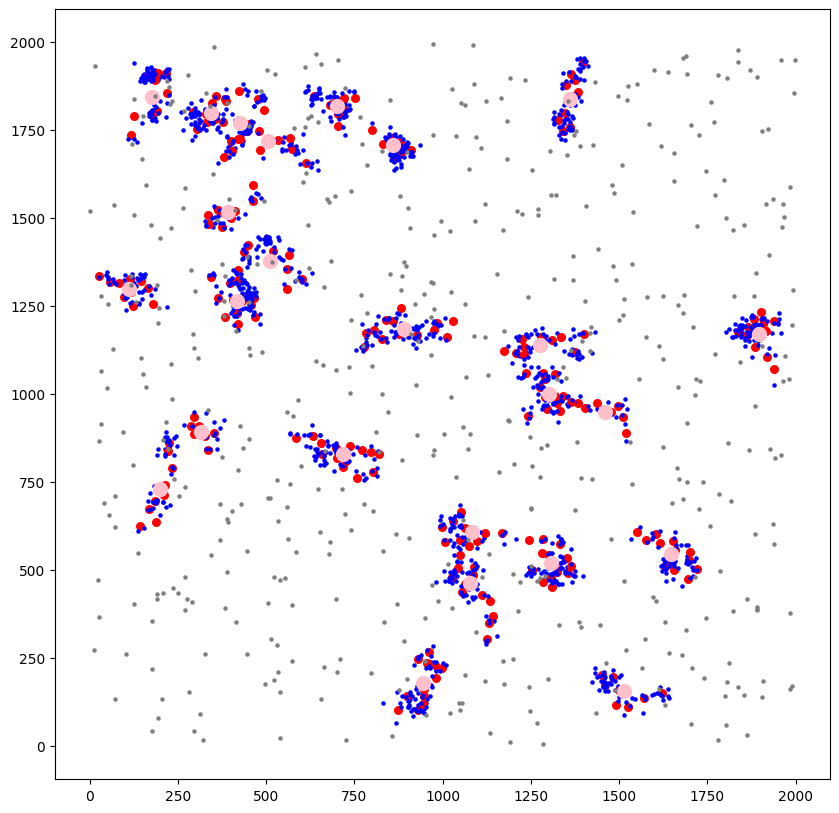

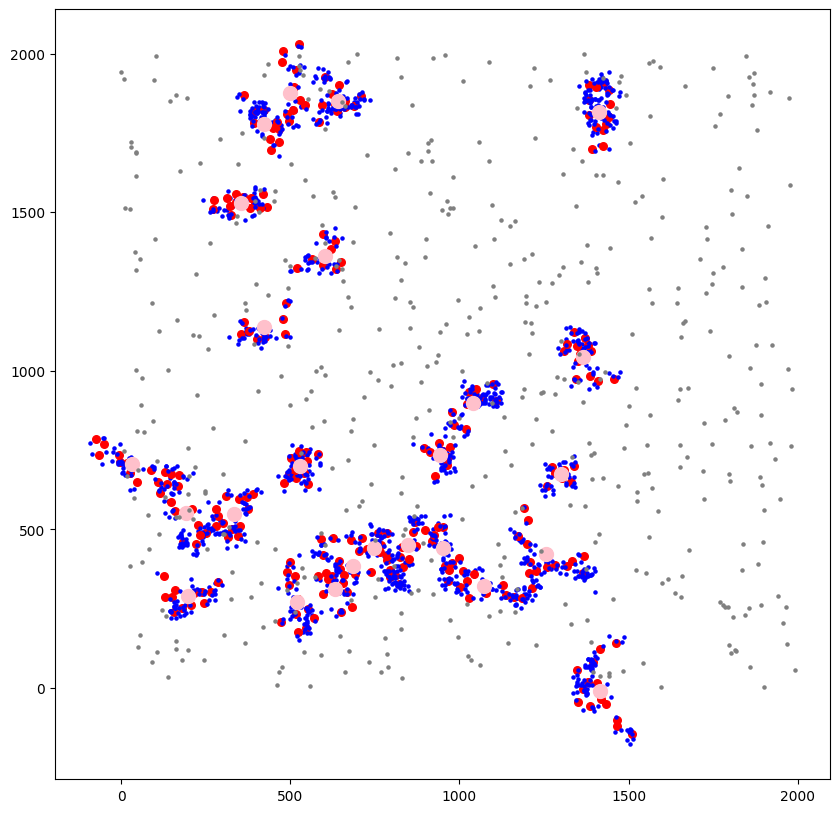

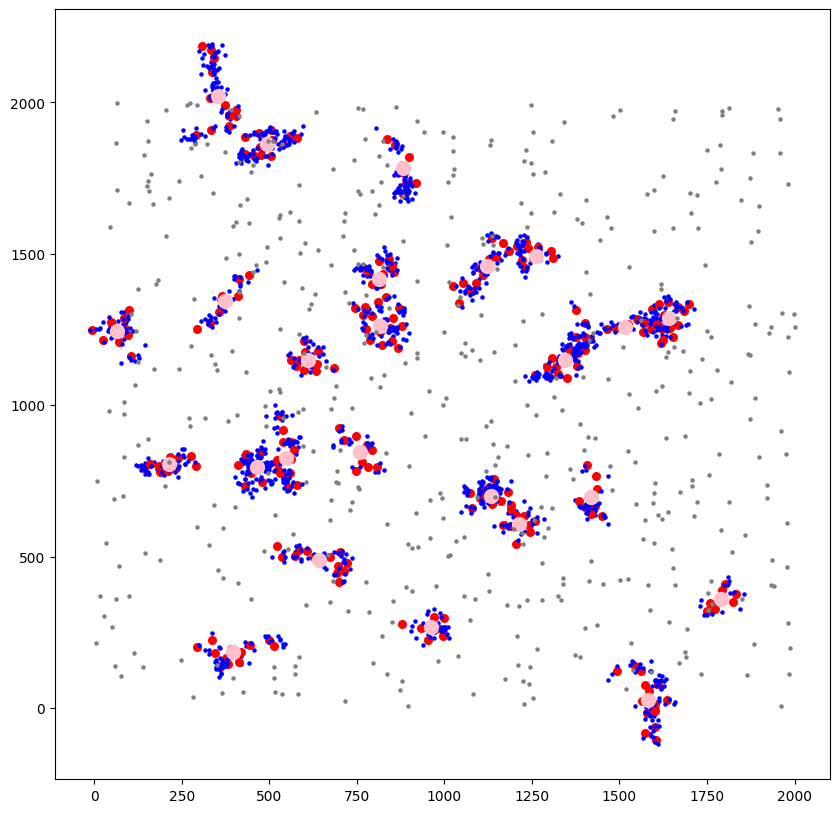

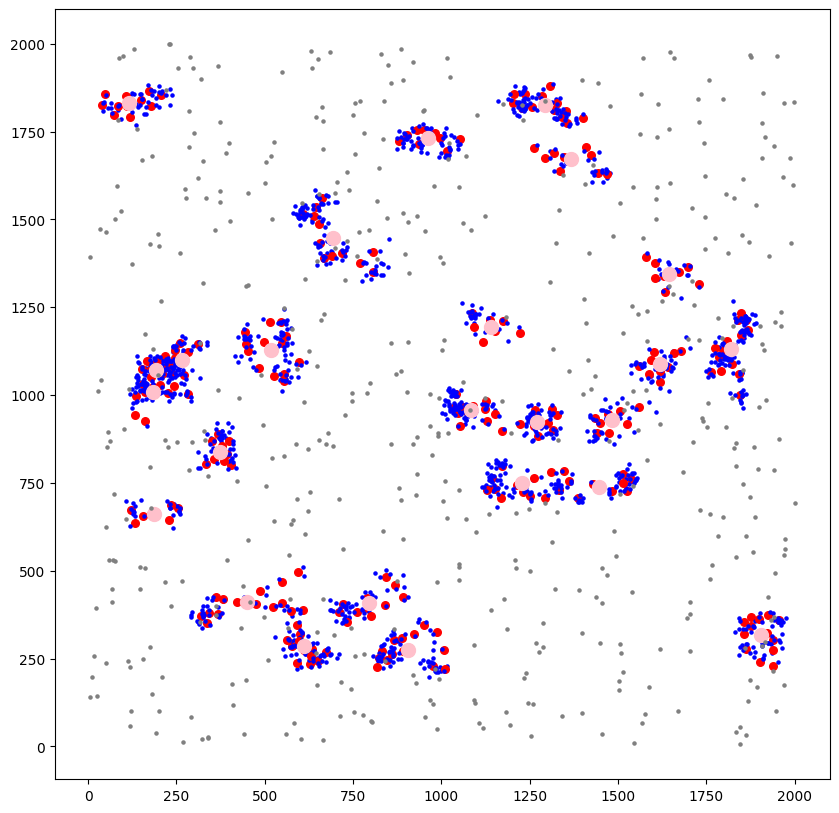

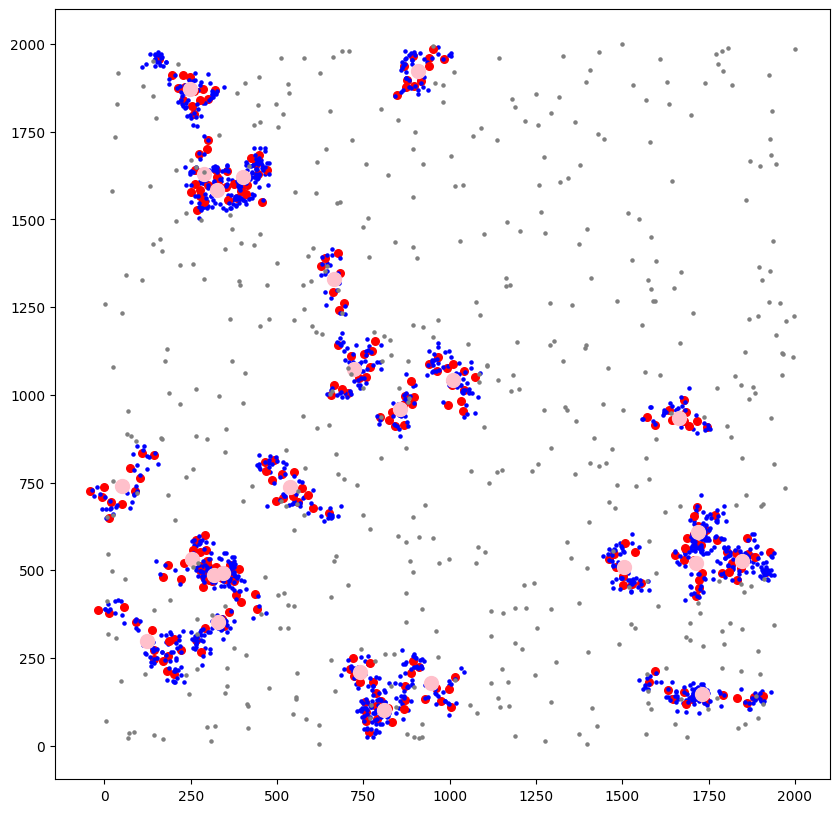

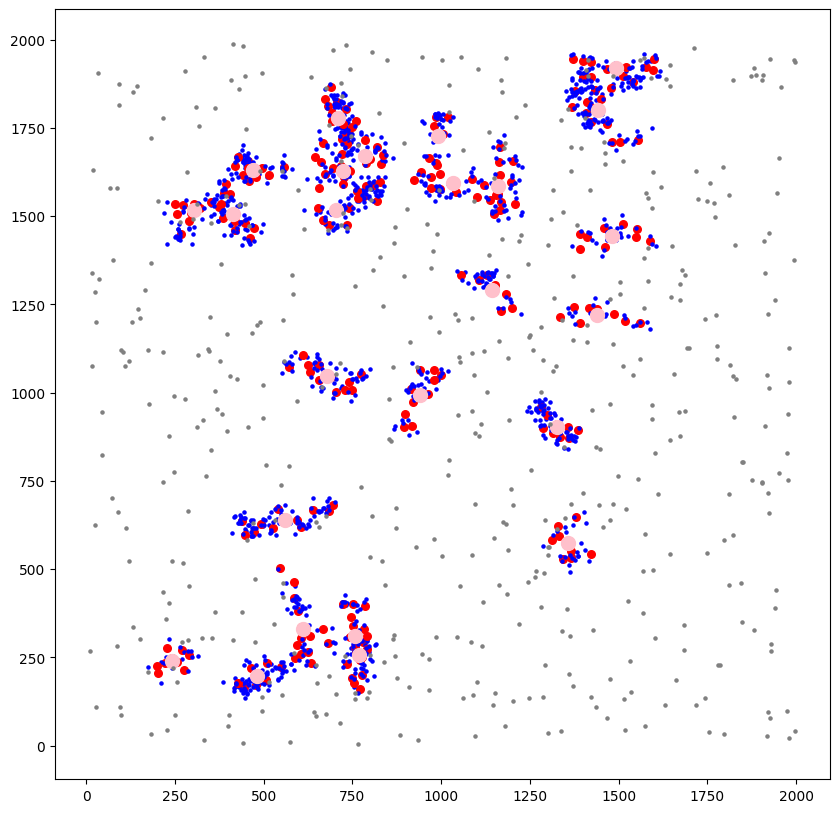

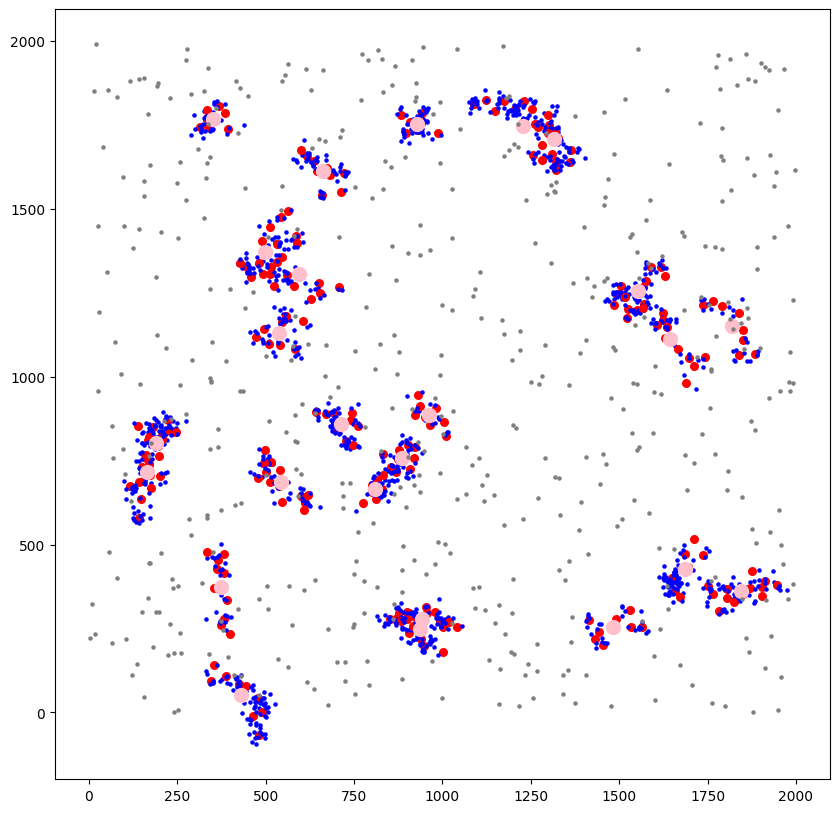

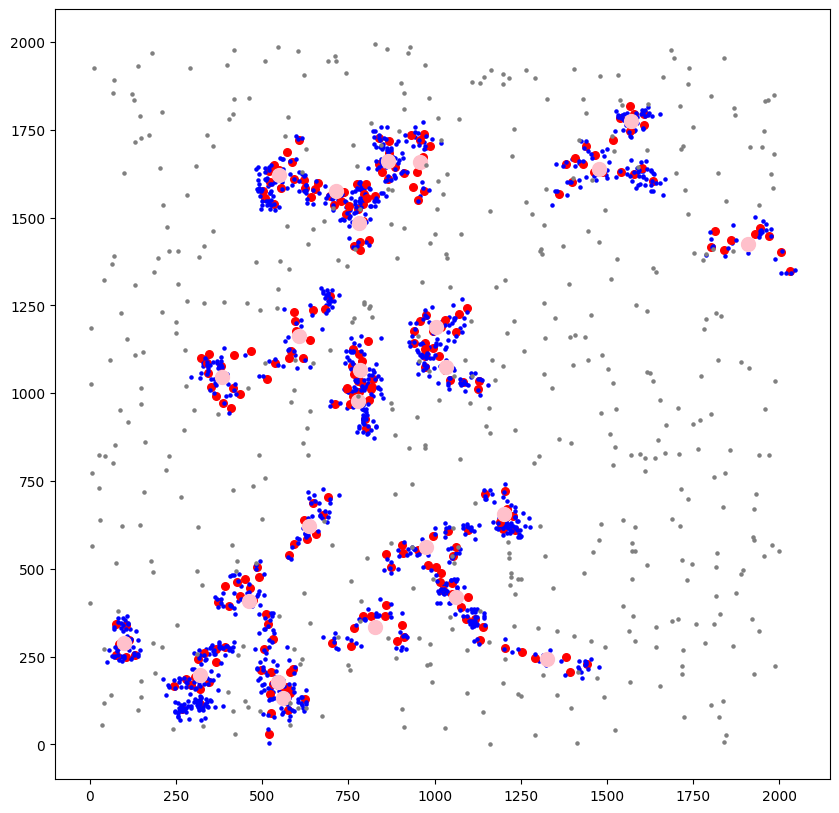

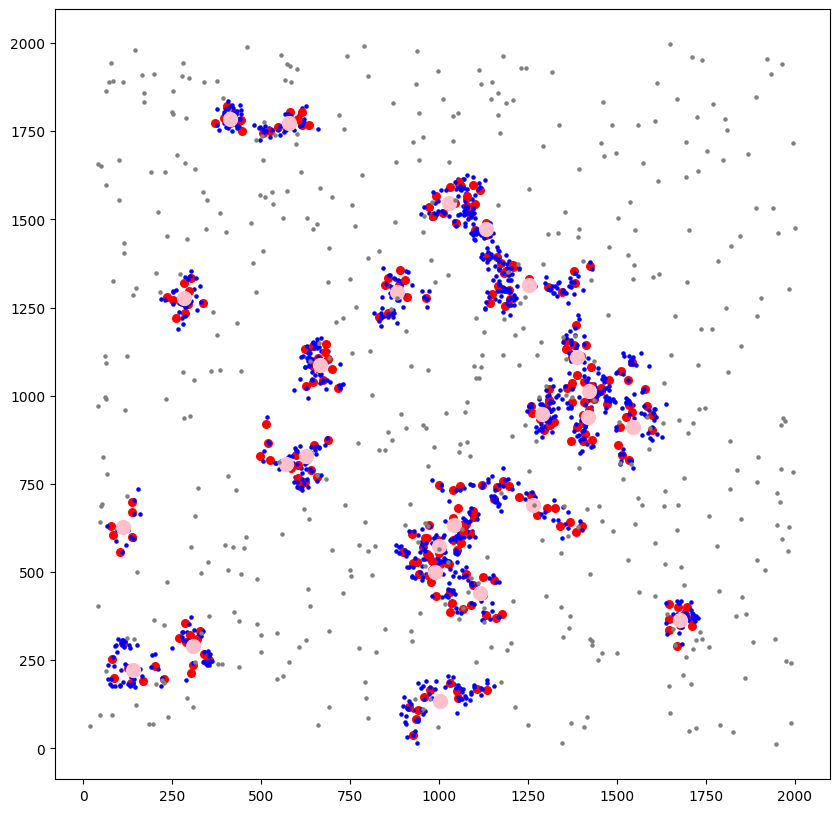

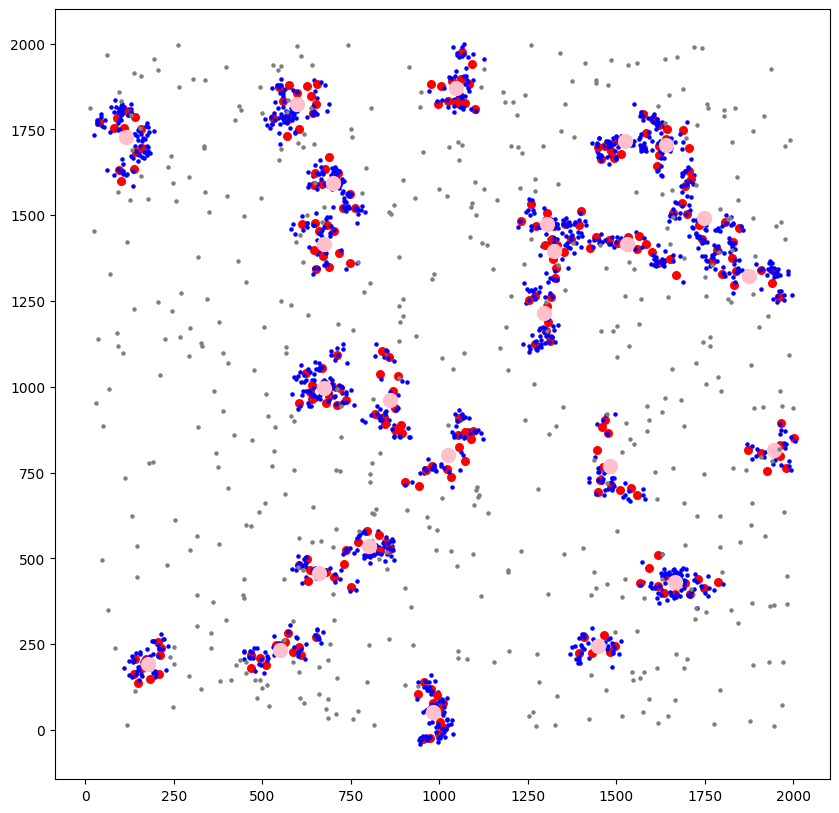

In [ ]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

def generate_chain_cluster(start, n_proteins, link_min, link_max, overlap_min, max_tries=1000):
    proteins = [np.array(start, dtype=float)]

    for _ in range(1, n_proteins):
        placed = False

        for _ in range(max_tries):
            angle = np.random.uniform(0, 2 * np.pi)
            step = np.random.uniform(link_min, link_max)
            candidate = proteins[-1] + step * np.array([np.cos(angle), np.sin(angle)])

            if all(np.linalg.norm(candidate - p) >= overlap_min for p in proteins):
                proteins.append(candidate)
                placed = True
                break

        if not placed:
            break

    proteins = np.array(proteins)
    center = np.mean(proteins, axis=0)   # centroid of all proteins

    return proteins, center


H = 2000
W = H
lim = 100

number_of_clusters = 25
# mean_number_of_proteins = 4
# stddev_number_of_proteins = 0
min_number_of_proteins = 7
max_number_of_proteins = 14
mean_number_of_proteins = (min_number_of_proteins + max_number_of_proteins) / 2
# stdev_cluster_radius = 50
link_min = 20      # minimum distance to previous protein
link_max = 60      # maximum distance to previous protein
overlap_min = link_min 
p_geo = 1/5 # 1 means that the mean number of localizations per protein is 1/p_geo
stdev_loc_prec = 15
noise_level = 1 * number_of_clusters * mean_number_of_proteins * (1/p_geo) # noise level as a function of the number of clusters, proteins and localizations

disp = True

output_folder = "csv_generats"
os.makedirs(output_folder, exist_ok=True)

for run in range(10):
    seed_coord = np.random.uniform(lim, H-lim, size=(number_of_clusters, 2))
    cluster_coord = np.zeros((number_of_clusters, 2))
    noise_coord = np.random.uniform(0, H, size=(int(noise_level), 2))

    index_protein = 0
    index_cluster = 0

    data= []

    if disp:
        fig = plt.figure(figsize=(10, 10))


    for i in range(number_of_clusters):
        index_cluster = index_cluster + 1
        number_of_proteins = np.random.randint(min_number_of_proteins, max_number_of_proteins + 1)
        # number_of_proteins=np.random.normal(mean_number_of_proteins, stddev_number_of_proteins)
        # number_of_proteins = number_of_proteins if number_of_proteins > 0 else 1  

        protein_coord, cc  = generate_chain_cluster(
                                                seed_coord[i], 
                                                number_of_proteins, 
                                                link_min, 
                                                link_max, 
                                                overlap_min
                                                )
        
    
        cluster_coord[i, :]= cc

        for x,y in protein_coord:

            index_protein = index_protein + 1

            if disp:
                plt.scatter(x, y, color='red', s=30)

            number_of_locs = np.random.geometric(p=p_geo)
            for k in range(number_of_locs):
                x_loc = x + np.random.normal(0, stdev_loc_prec)
                y_loc = y + np.random.normal(0, stdev_loc_prec)

                data.append([x_loc, y_loc, index_cluster])

                if disp:
                    plt.scatter(x_loc, y_loc, color='blue', s=5)

    if disp:
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='pink', s=100, label='Cluster Centers')
        plt.scatter(noise_coord[:, 0], noise_coord[:, 1], color='gray', s=5, label='Noise')


    for i in range(len(noise_coord)):
        x_noise = noise_coord[i, 0]
        y_noise = noise_coord[i, 1]
        data.append([x_noise, y_noise, 0])
    
    df = pd.DataFrame(data, columns=["x", "y", "index"])
    filename = f"simulated_clusters_CM_{run+1}.csv"
    output_path = os.path.join(output_folder, filename)
    df.to_csv(output_path, index=False)

    print(f"CSV guardado en: {output_path}")